# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


In [35]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# import dataset from Kaggle
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Import the kagglehub library to access datasets from Kaggle
import kagglehub

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Dataset Overview

This dataset comprises five distinct scenarios: benchmark toy dataset, clinical trials, e-commerce, environment, and marketing. Each scenario contains four variables, and we will identify instrumental variables and explore the relationships between them.

In [36]:
# Run this cell if it is running on Colab Notebook. 
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
# import kagglehub
# from kagglehub import KaggleDatasetAdapter

# Load the data
# Set file path to the dataset
# file_path = "/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv"

# Load the latest version
# df = kagglehub.load_dataset(
#   KaggleDatasetAdapter.PANDAS,
#   "cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025",
#   file_path,
# )

# Display the first 5 records of the dataset
# print("First 5 records:", df.head())


In [37]:
# Run this cell if it is running on Kaggle Notebook.
# Load causal_direction_iv dataset
base_path = "/kaggle/input/datasets/cloverchen/causalpitfalls-benchmark-causal-data-neurips-2025/CausalPitfallsData/causal_direction_iv"

# Define the dataset file names
files = {
    "data":      "causal_direction_iv_sem.csv",
    "data_ct":   "clinical_trial_sem.csv",
    "data_ecom": "ecommerce_sem.csv",
    "data_env":  "environment_sem.csv",
    "data_mkt":  "marketing_sem.csv",
}

# Load datasets into a dictionary
datasets = {}
for var_name, filename in files.items():
    full_path = f"{base_path}/{filename}"
    datasets[var_name] = pd.read_csv(full_path)

# Assign datasets to variables for easier access
data      = datasets["data"]
data_ct   = datasets["data_ct"]
data_ecom = datasets["data_ecom"]
data_env  = datasets["data_env"]
data_mkt  = datasets["data_mkt"]

# Explore structure of all datasets
for name, df in datasets.items():
    print(f"\n==== {name} ====")
    # basic shape
    print("Shape:", df.shape)
    
    # preview
    print("Head:")
    print(df.head())


==== data ====
Shape: (1000, 4)
Head:
        Z_1       Z_2       X_1       X_2
0  0.097627  0.185761 -0.495165  0.465218
1  0.430379 -0.979873  1.787126  2.317646
2  0.205527 -0.048348  1.155494  2.901568
3  0.089766  0.417541  0.998256  2.608056
4 -0.152690 -0.912049  0.670800 -0.575962

==== data_ct ====
Shape: (1000, 4)
Head:
   baseline_health  dosage_mg  drug_concentration  health_improvement
0         0.417022  23.032399           33.589587           23.614753
1         0.720324  45.593094           69.246066           51.456062
2         0.000114  40.068309           60.868536           41.340428
3         0.302333  40.505284           62.482962           46.217086
4         0.146756  28.779161           42.263672           29.639678

==== data_ecom ====
Shape: (1000, 4)
Head:
         age        income     visits   purchases
0  43.794235  83359.224370  34.442595  875.697981
1  51.613900  30905.732609  42.647868  361.745160
2  46.329879  72824.357627  38.013870  775.654642
3  

## Handling Missing Values

In [38]:
# Check for missing values
for name, df in datasets.items():
    print(f"\n==== {name} ====")
    
    # missing values per column
    mv = df.isnull().sum()
    print("\nMissing values per column:")
    print(mv)

    # total missing
    total_mv = mv.sum()
    print("Total missing values:", total_mv)


==== data ====

Missing values per column:
Z_1    0
Z_2    0
X_1    0
X_2    0
dtype: int64
Total missing values: 0

==== data_ct ====

Missing values per column:
baseline_health       0
dosage_mg             0
drug_concentration    0
health_improvement    0
dtype: int64
Total missing values: 0

==== data_ecom ====

Missing values per column:
age          0
income       0
visits       0
purchases    0
dtype: int64
Total missing values: 0

==== data_env ====

Missing values per column:
rainfall_mm      0
fertilizer_kg    0
soil_quality     0
crop_yield       0
dtype: int64
Total missing values: 0

==== data_mkt ====

Missing values per column:
ad_spend_k         0
promo_spend_k      0
brand_awareness    0
sales              0
dtype: int64
Total missing values: 0


## Feature Distributions

Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.



Plotting hist for: data


<Figure size 1200x1200 with 0 Axes>

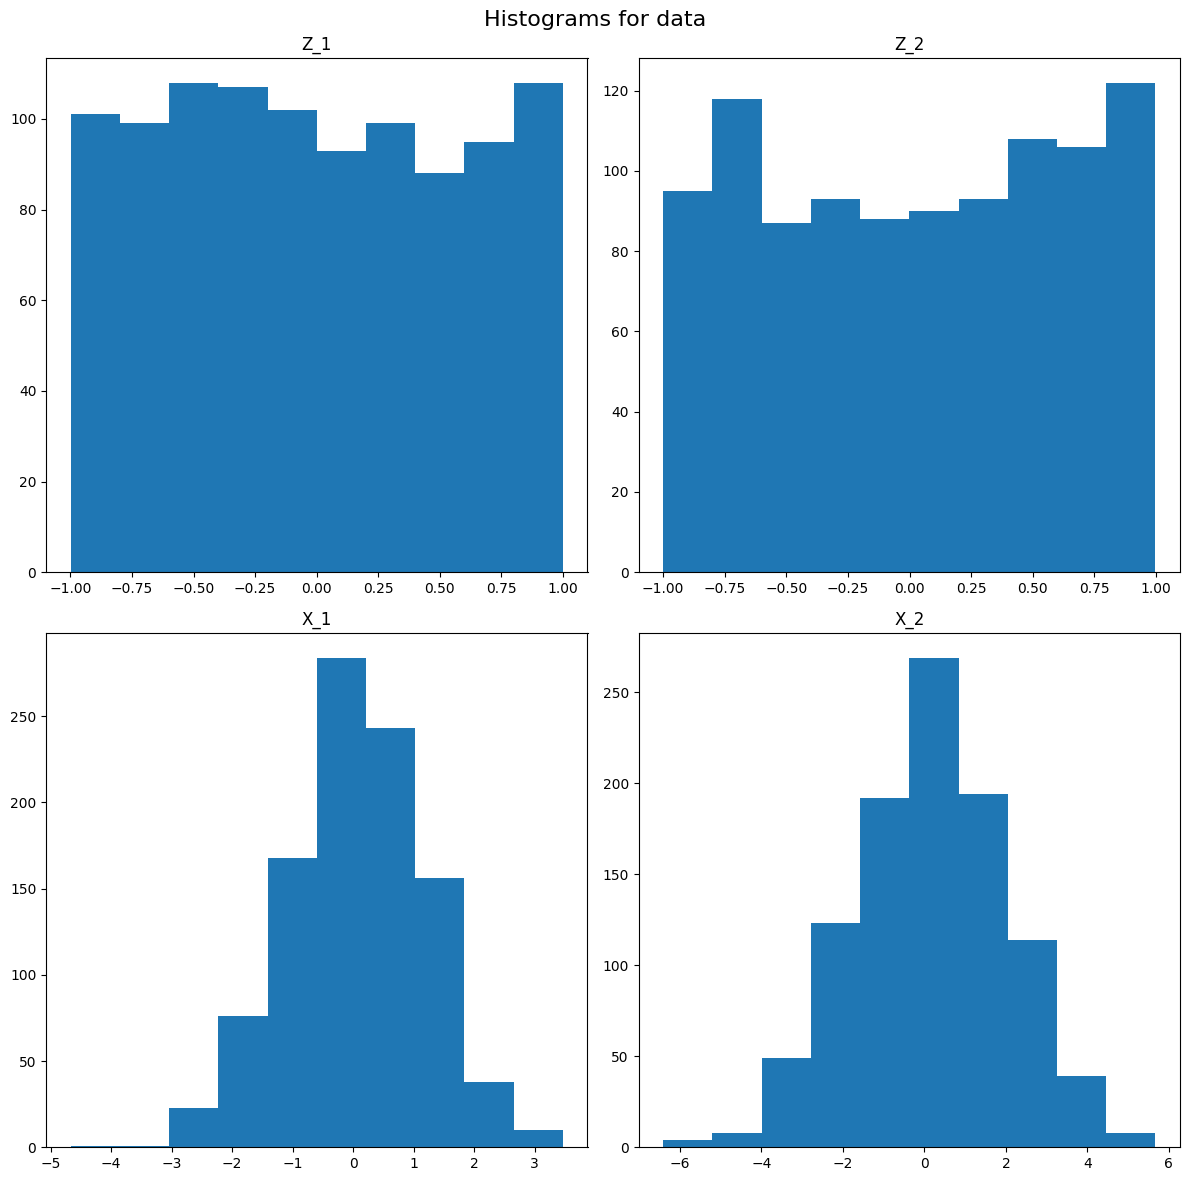


Plotting hist for: data_ct


<Figure size 1200x1200 with 0 Axes>

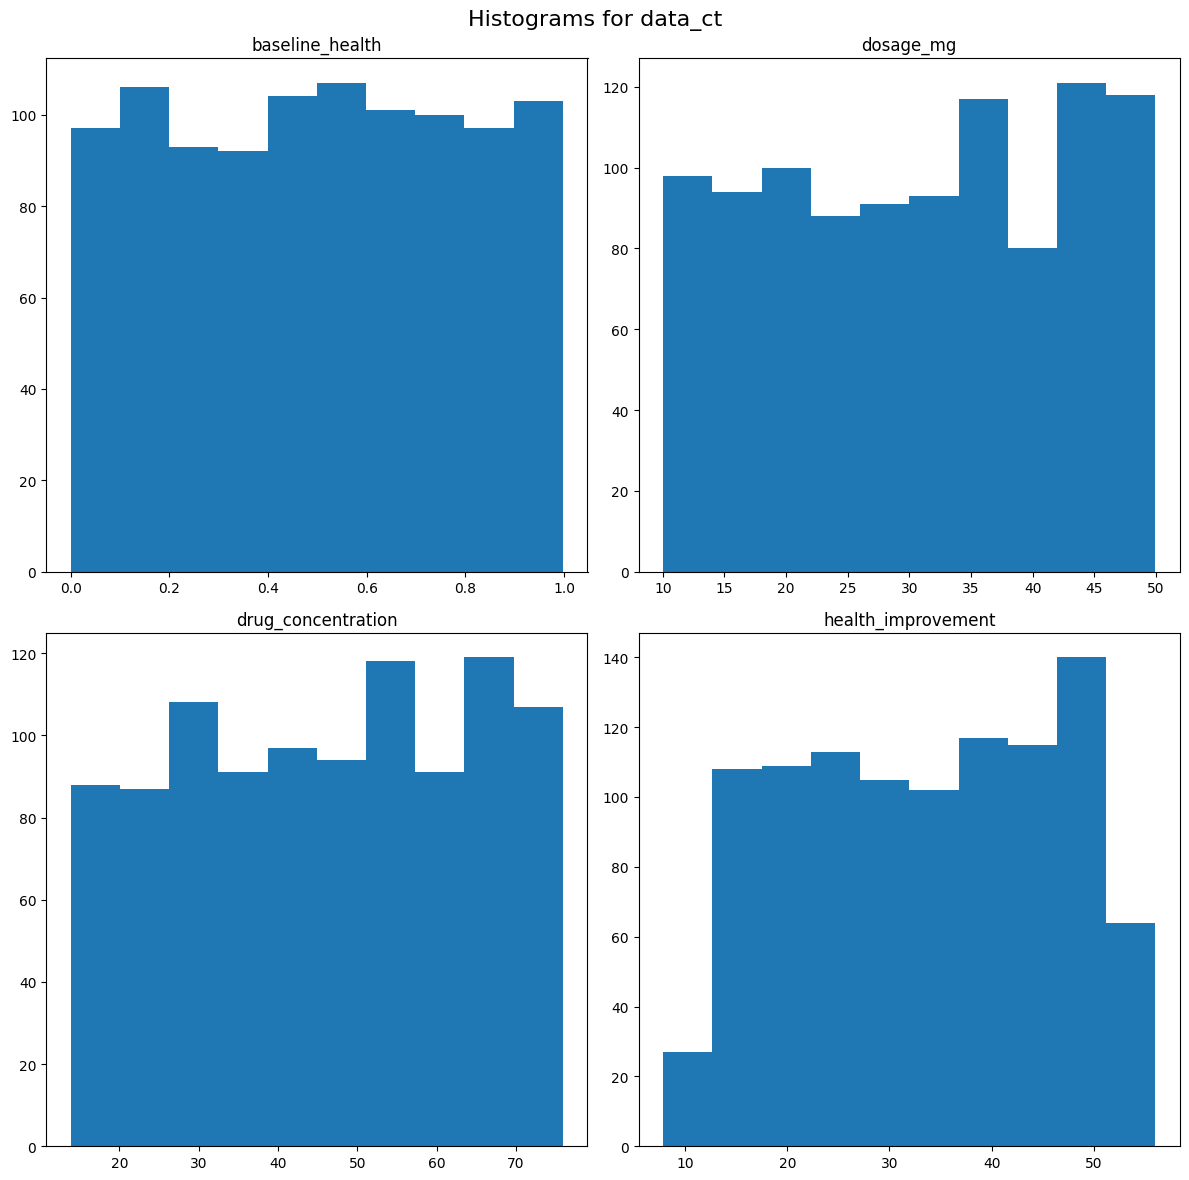


Plotting hist for: data_ecom


<Figure size 1200x1200 with 0 Axes>

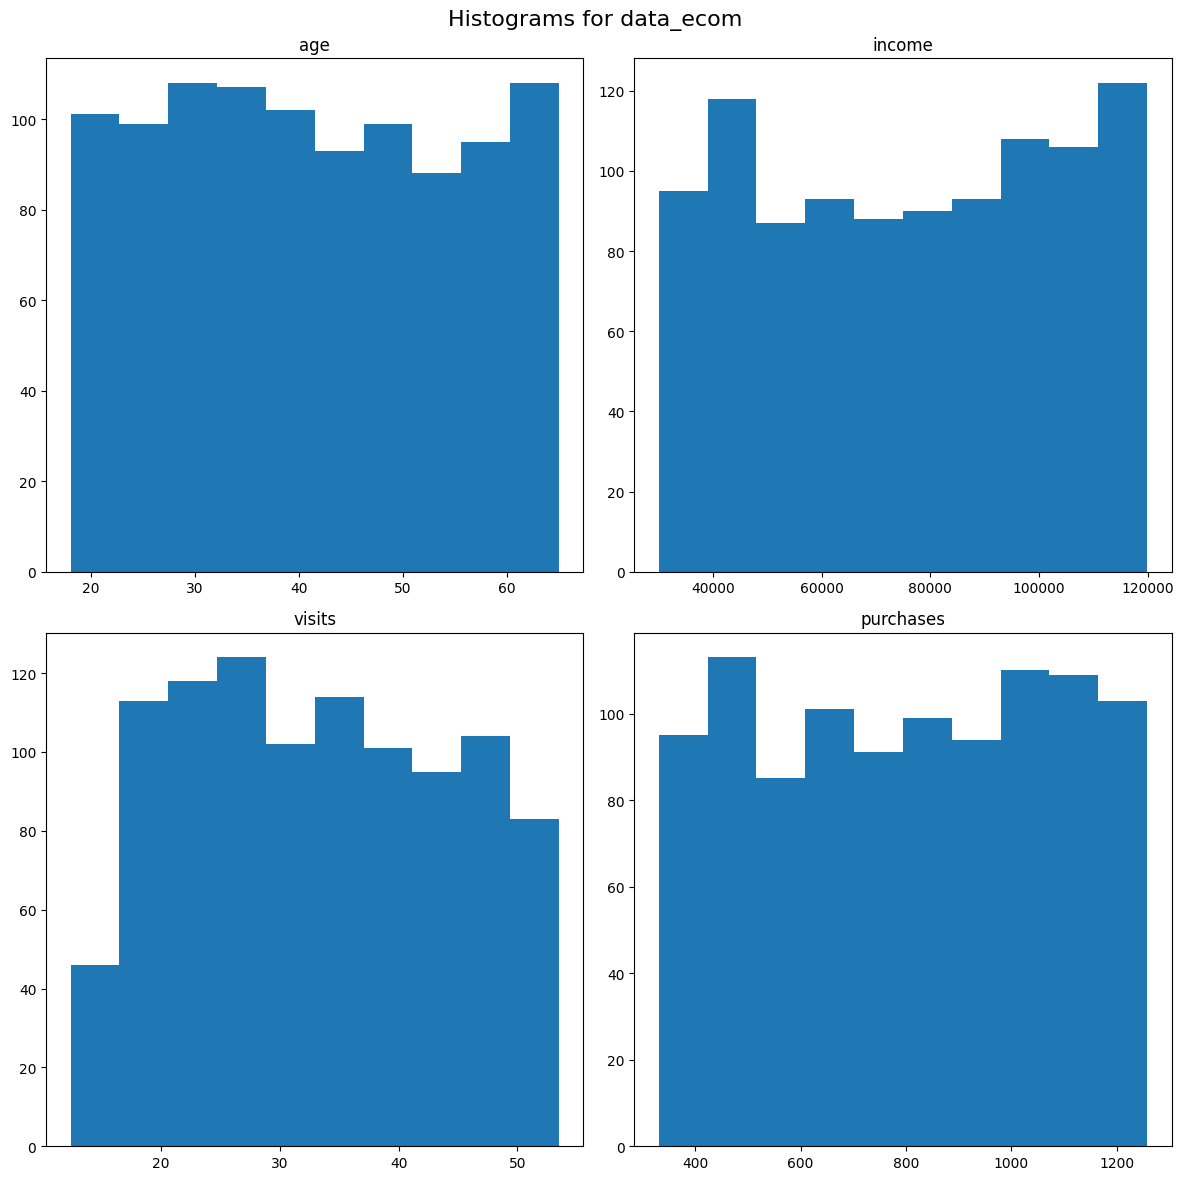


Plotting hist for: data_env


<Figure size 1200x1200 with 0 Axes>

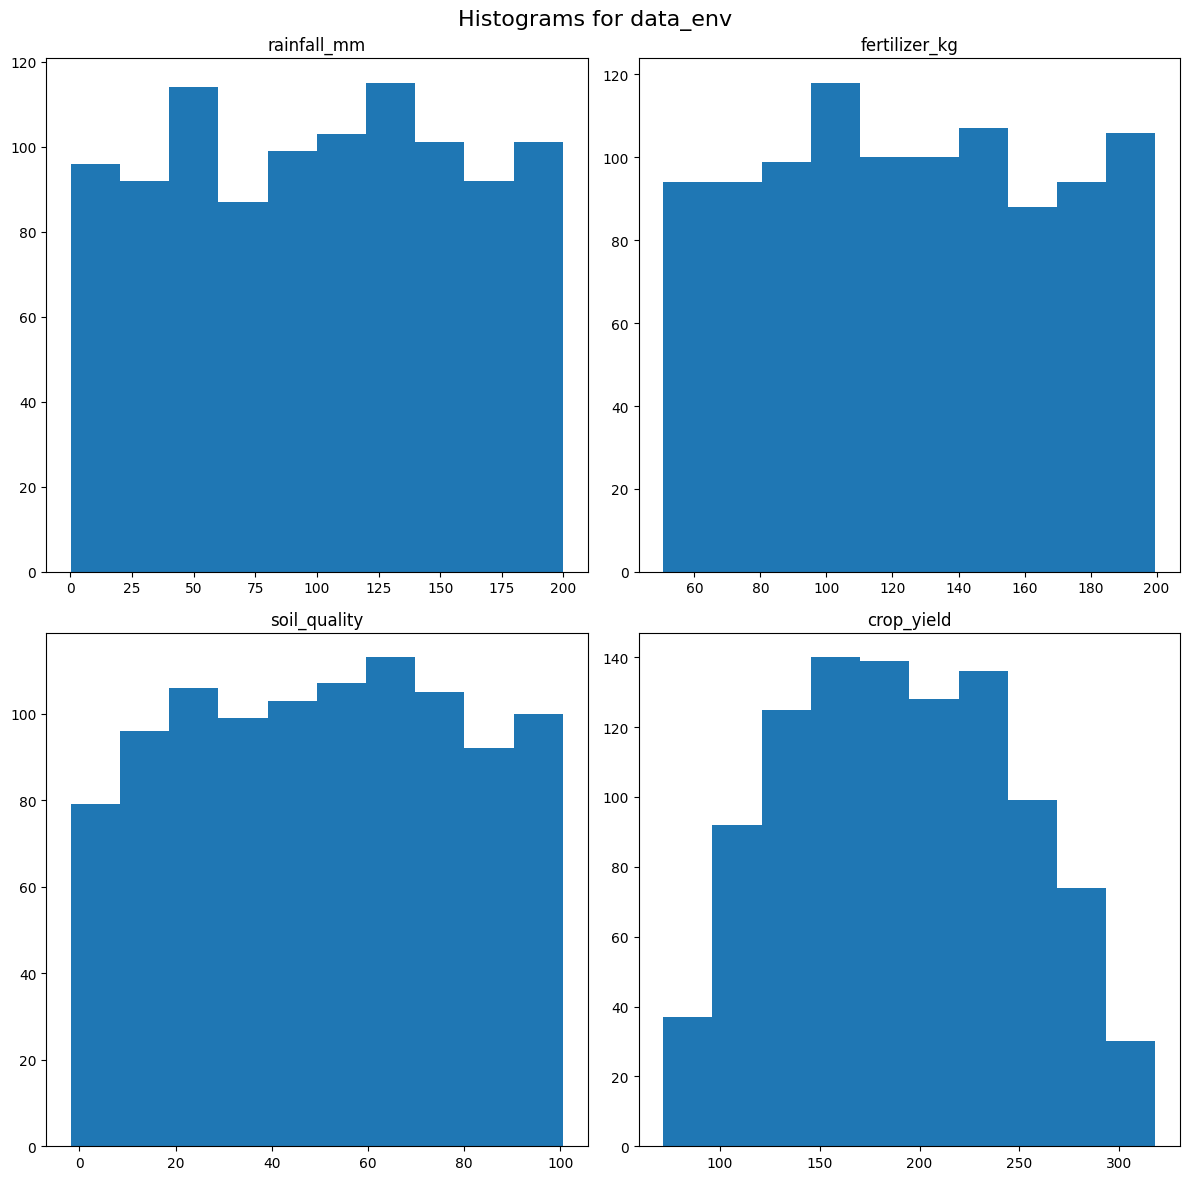


Plotting hist for: data_mkt


<Figure size 1200x1200 with 0 Axes>

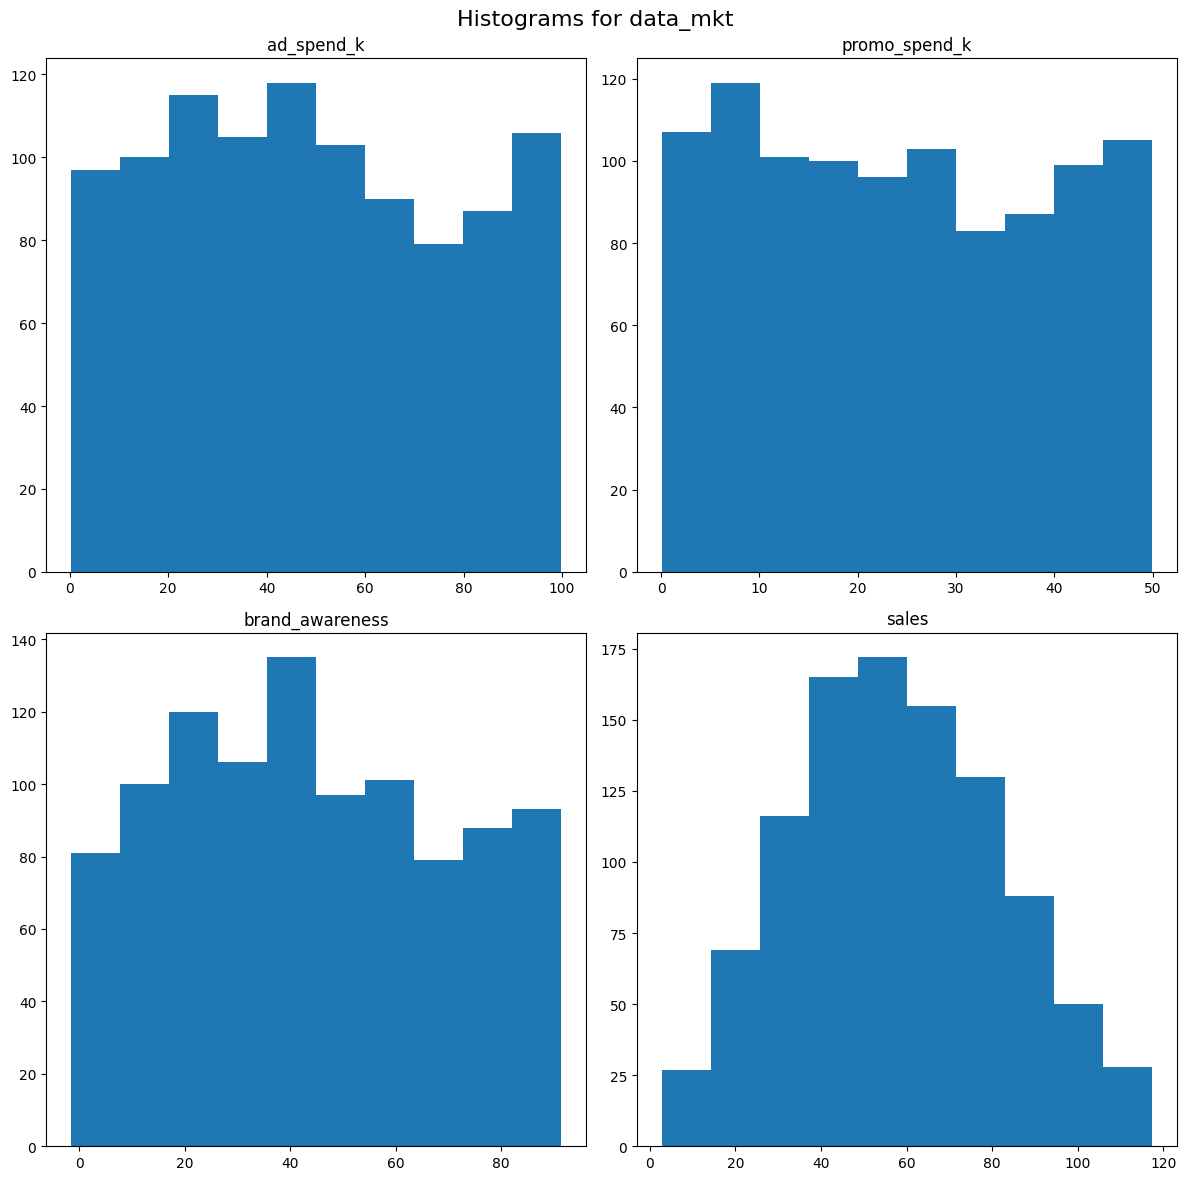

In [39]:
# Plotting histograms of all numerical features
for name, df in datasets.items():
    print(f"\nPlotting hist for: {name}")
    plt.figure(figsize=(12, 12))
    df.hist(figsize=(12, 12), grid=False)
    plt.suptitle(f"Histograms for {name}", fontsize=16)
    plt.tight_layout()
    plt.show()

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


<Figure size 1200x600 with 0 Axes>

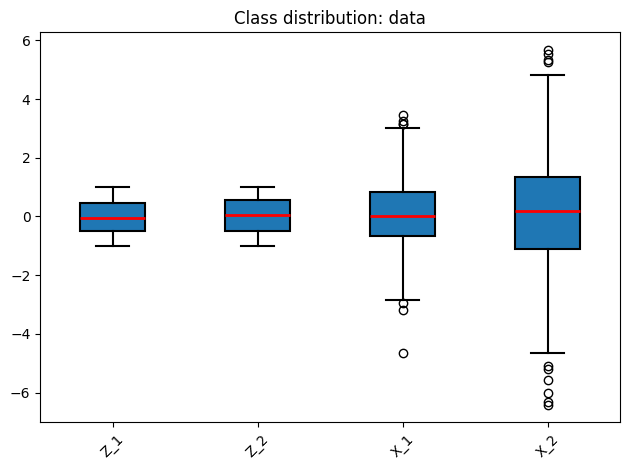

<Figure size 1200x600 with 0 Axes>

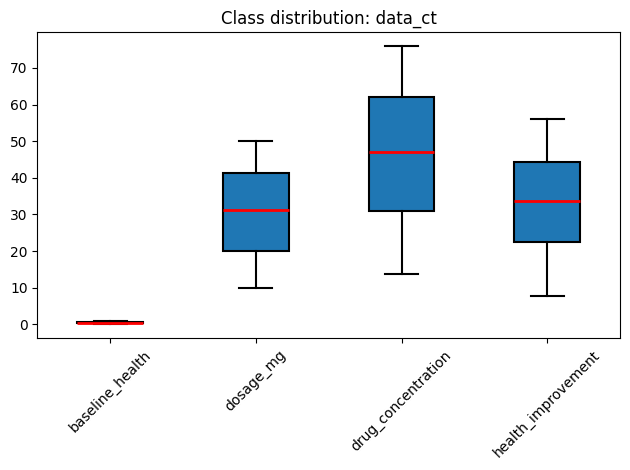

<Figure size 1200x600 with 0 Axes>

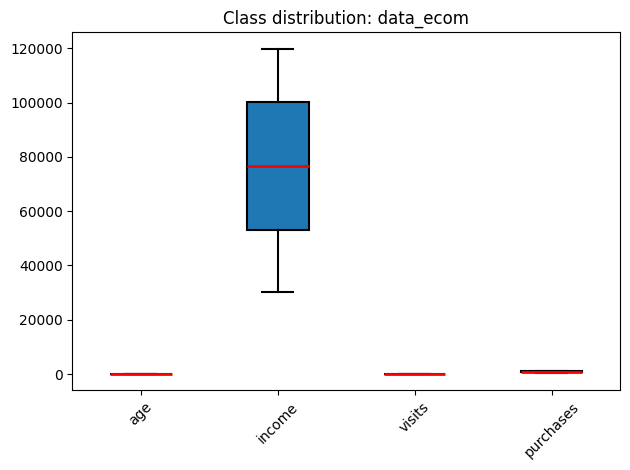

<Figure size 1200x600 with 0 Axes>

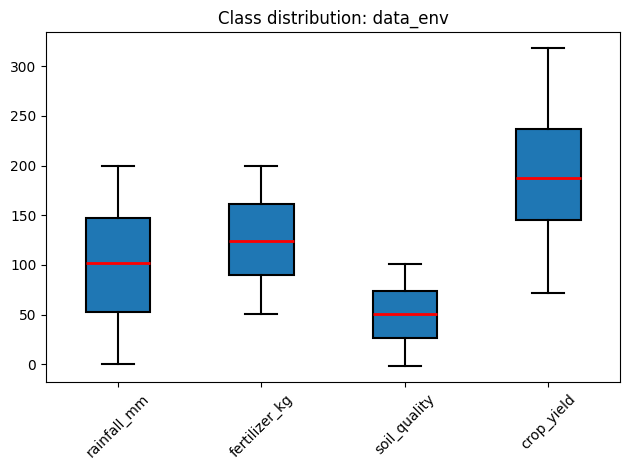

<Figure size 1200x600 with 0 Axes>

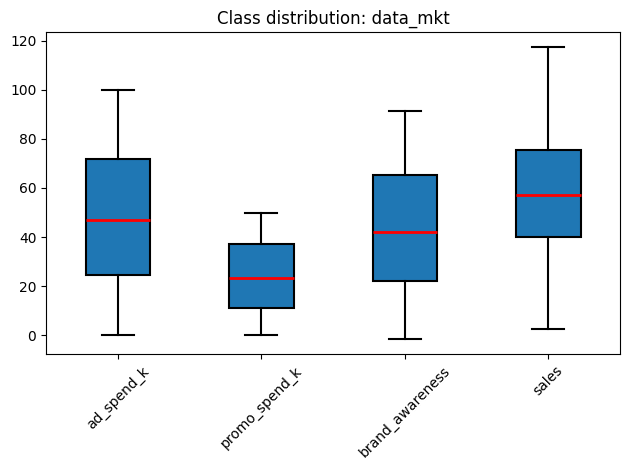

In [40]:
# Plotting boxplots of all numerical features

# Set color 
colors = dict(
    boxes="black",
    whiskers="black",
    medians="red",
    caps="black",
)

boxprops    = dict(linestyle="-", linewidth=1.5)
medianprops = dict(linestyle="-", linewidth=2, color="red")
whiskerprops = dict(linestyle="-", linewidth=1.5)
capprops     = dict(linestyle="-", linewidth=1.5)

# Plot boxplots for each dataset
for name, df in datasets.items():
    num_cols = df.select_dtypes(include="number").columns
    plt.figure(figsize=(12, 6))
    df[num_cols].plot.box(
        patch_artist=True,
        color=colors,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
    )
    plt.title(f"Class distribution: {name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Correlations

Explore correlations between features and the target variable, as well as among features themselves.


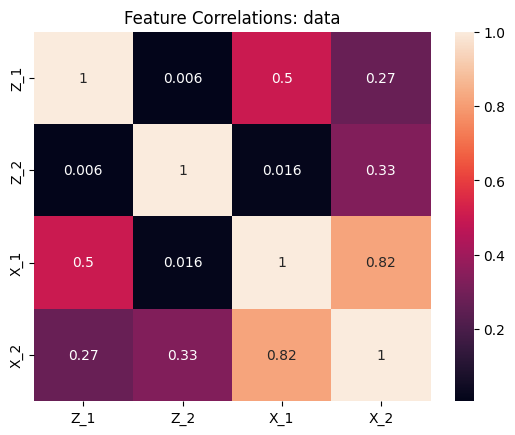

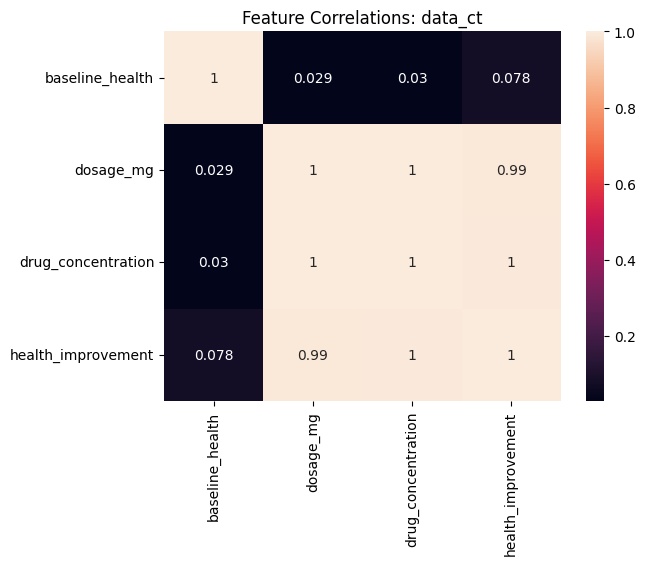

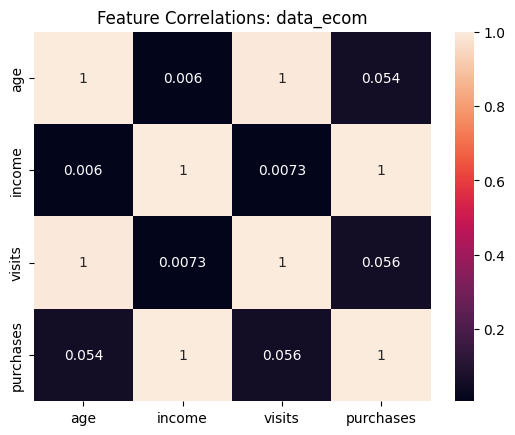

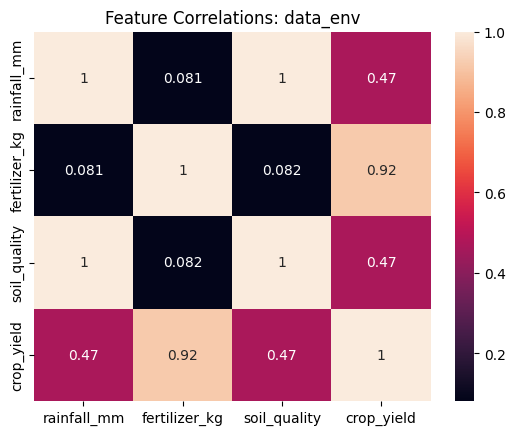

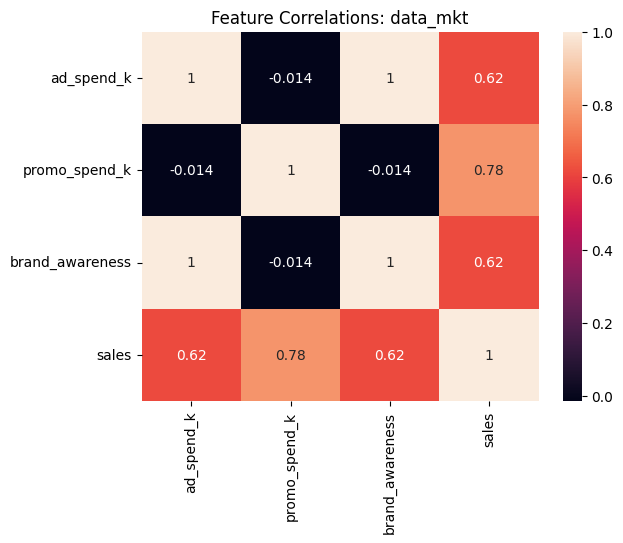

In [41]:
# Plotting heatmaps to show feature correlations
for name, df in datasets.items():
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True)
    plt.title(f"Feature Correlations: {name}")
    plt.show()

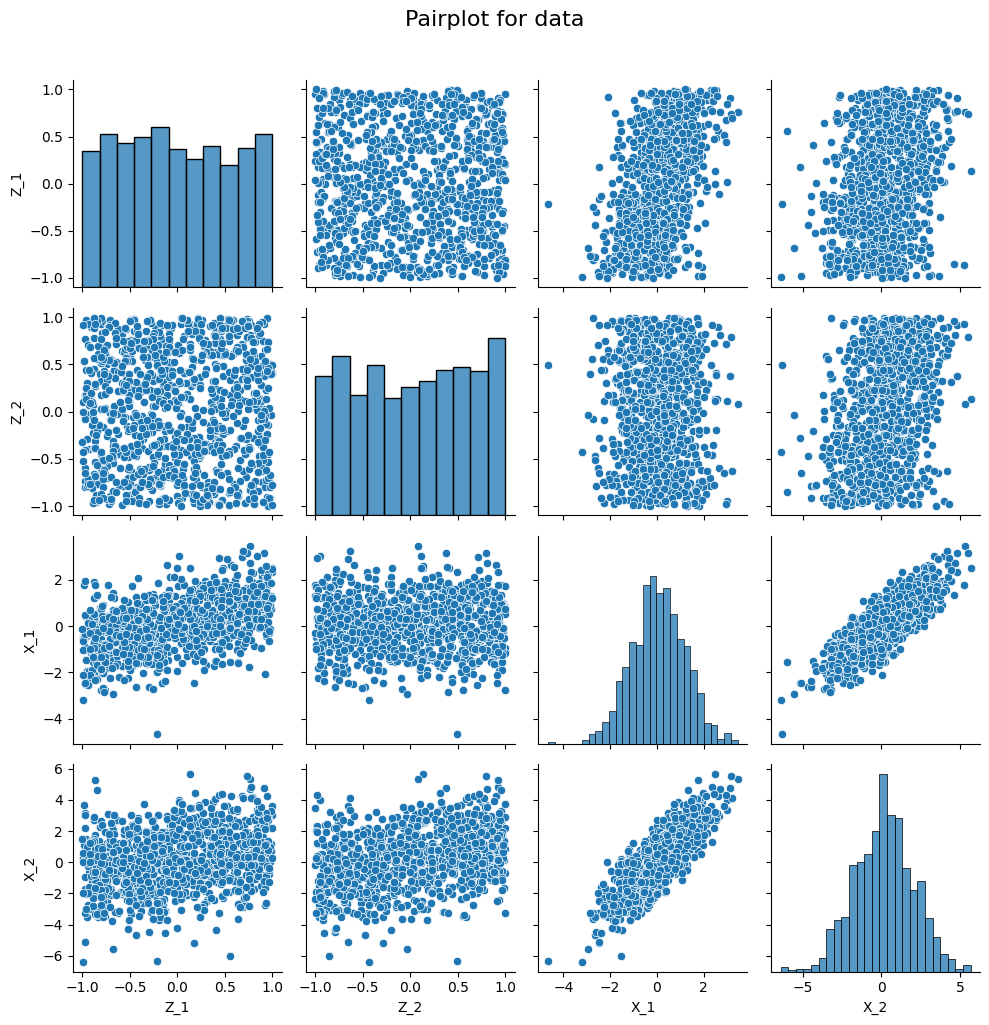

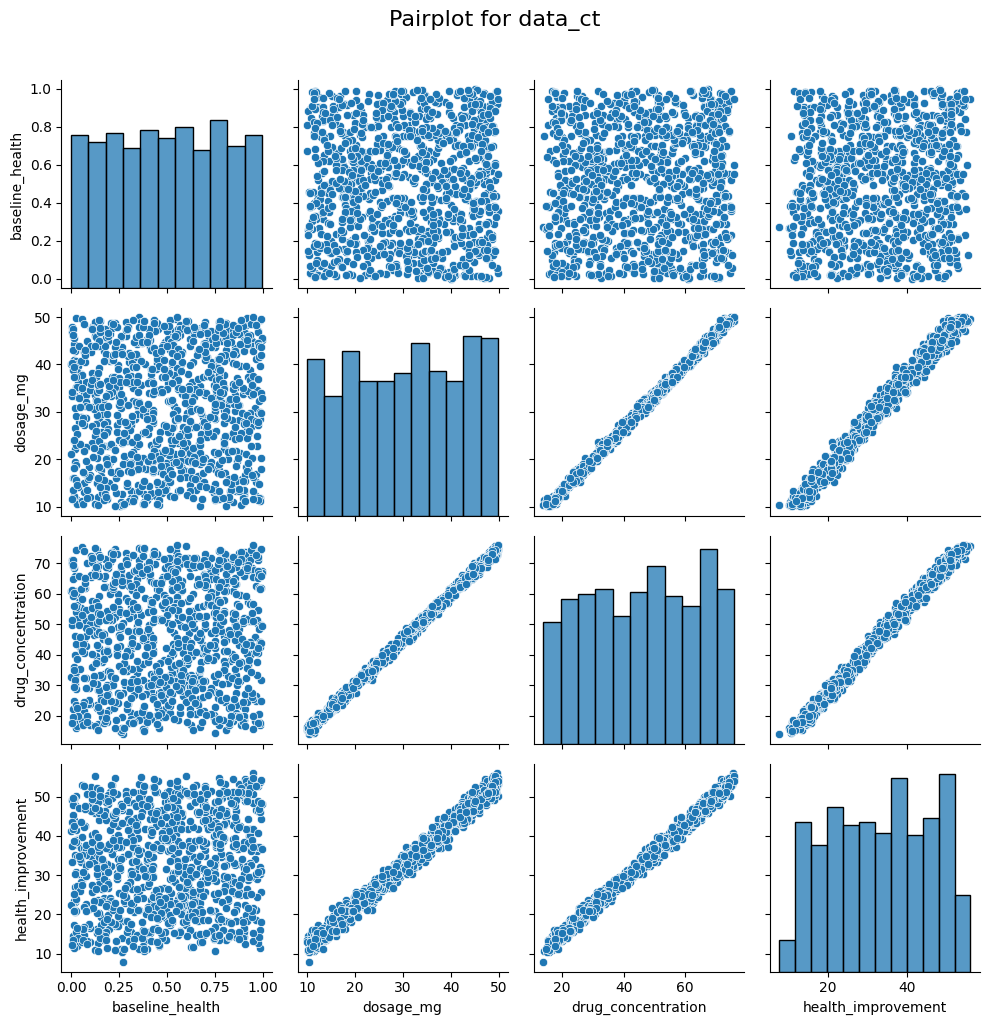

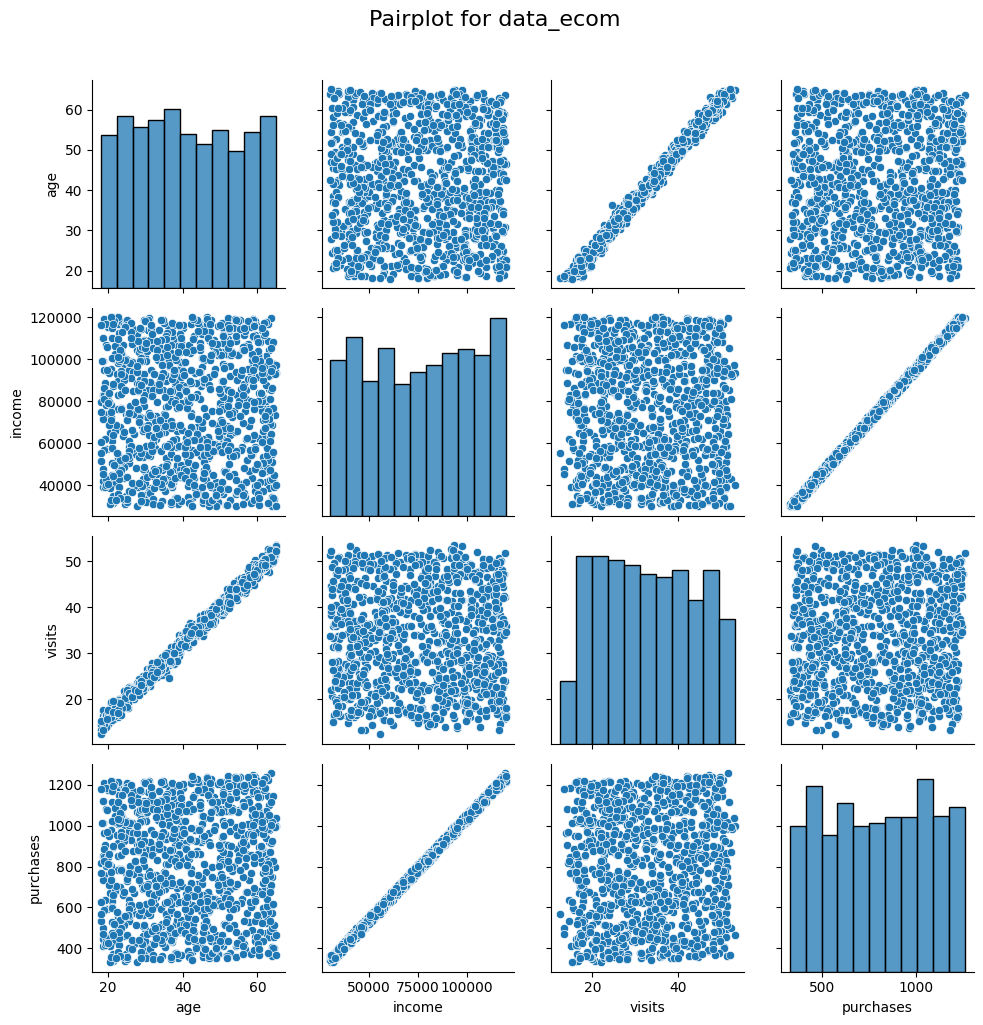

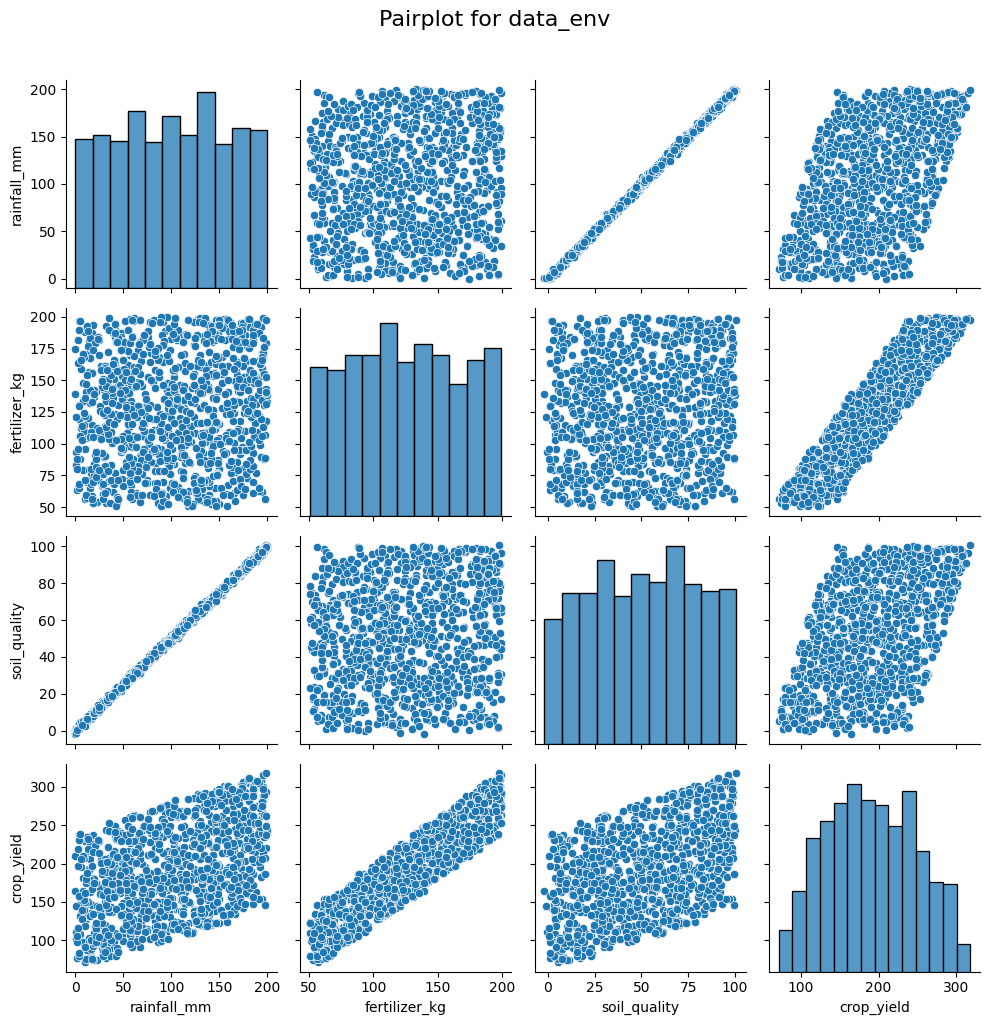

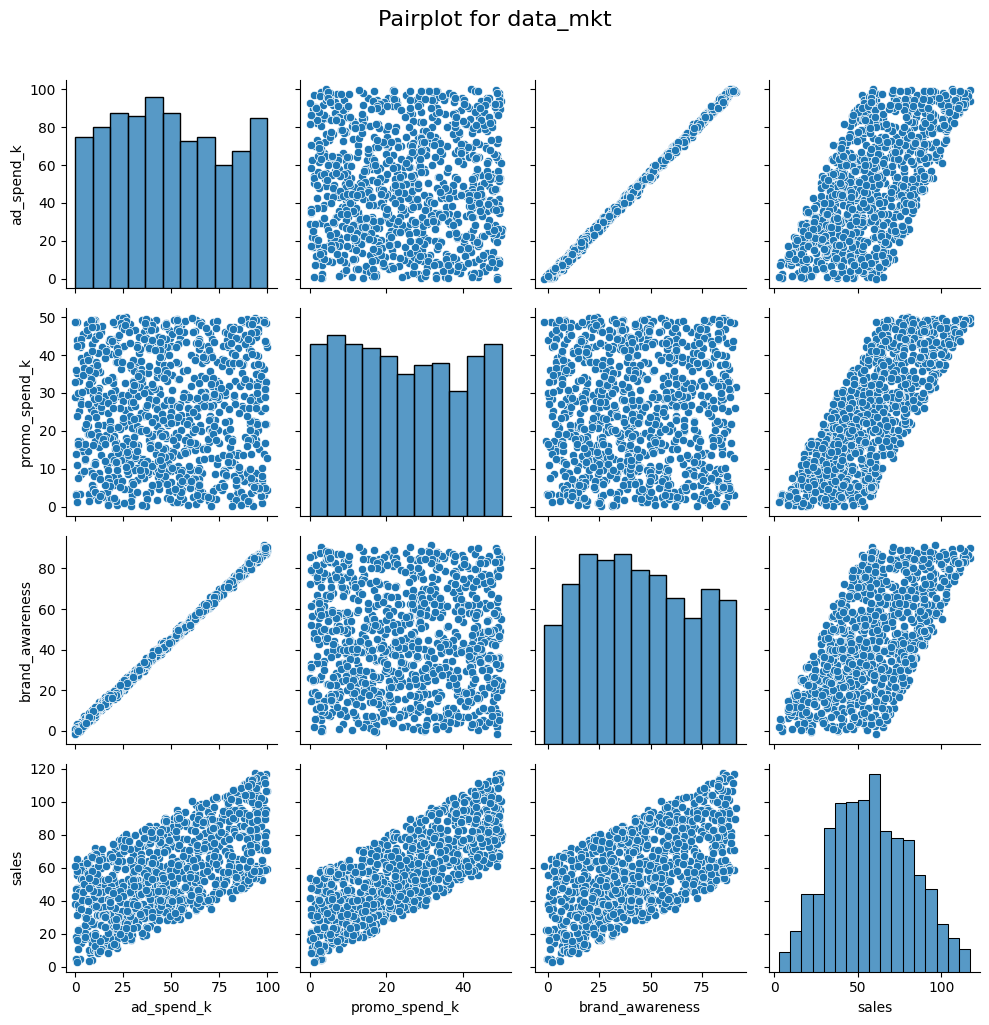

In [42]:
# Plotting pairplots 
for name, df in datasets.items():
    g = sns.pairplot(df)
    g.fig.suptitle(f"Pairplot for {name}", y=1.02, fontsize=16)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.95) 
